1. SETUP

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import time
import joblib

# Manejo de datos
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# Detecta la raíz del proyecto.
# Como este notebook está dentro de /notebooks,
# usamos ".." para subir a la raíz del proyecto.
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz al path de Python para importar:
# - utils.config
# - services.ingestion
# - services.preprocessing
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración del proyecto y la recarga
# por si hiciste cambios recientes
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

# ---------------------------------------------------------
# Importa los servicios reutilizables de la arquitectura
# ---------------------------------------------------------
from services.ingestion.ingestion_service import IngestionService
from services.preprocessing.preprocessing_service import PreprocessingService

# ---------------------------------------------------------
# Muestra rutas importantes del flujo full
# ---------------------------------------------------------
print("FULL_DATASET_DIR:", config.FULL_DATASET_DIR)
print("FULL_CONSOLIDATED_PATH:", config.FULL_CONSOLIDATED_PATH)
print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

FULL_DATASET_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/processed
FULL_CONSOLIDATED_PATH: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/network_full_consolidated.parquet
FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. CREAR CARPETA DE ARTEFACTOS

In [2]:
# ---------------------------------------------------------
# Crea la carpeta donde se guardarán los artefactos
# del flujo completo (23 CSV)
# ---------------------------------------------------------
os.makedirs(config.FULL_ARTIFACTS_DIR, exist_ok=True)
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

3. CARGAR LOS CSV

In [3]:
# ---------------------------------------------------------
# Carga el dataset full desde parquet si ya existe.
# Si no existe, lee y concatena los 23 archivos CSV,
# mostrando en consola:
# - archivo actual
# - tiempo por archivo
# - tiempo total acumulado
# Luego guarda el consolidado en parquet para reutilizarlo.
# ---------------------------------------------------------

ingestion = IngestionService()

# ---------------------------------------------------------
# Intentar cargar primero desde parquet consolidado
# ---------------------------------------------------------
try:
    if os.path.exists(config.FULL_CONSOLIDATED_PATH):
        print("Parquet consolidado encontrado. Cargando desde:")
        print(config.FULL_CONSOLIDATED_PATH)

        parquet_start = time.time()

        df_full = pd.read_parquet(config.FULL_CONSOLIDATED_PATH)

        if df_full.empty:
            raise ValueError("El parquet consolidado existe pero está vacío.")

        parquet_elapsed = time.time() - parquet_start

        print(f"✔ Parquet cargado en {parquet_elapsed:.2f} seg")
        print("Shape del dataset full:", df_full.shape)

    else:
        raise FileNotFoundError("No existe el parquet consolidado.")

except Exception as e:
    print(f"⚠ No se pudo cargar el parquet consolidado: {e}")
    print("Leyendo y concatenando los 23 archivos CSV...\n")

    # listar primero los archivos para tener control del proceso
    files = ingestion.list_csv_files(config.FULL_DATASET_DIR)

    print(f"Se encontraron {len(files)} archivos CSV.\n")

    df_list = []
    global_start = time.time()

    for idx, file in enumerate(files, start=1):
        file_start = time.time()

        print(f"[{idx}/{len(files)}] Cargando dataset: {os.path.basename(file)}")

        temp_df = pd.read_csv(file)
        df_list.append(temp_df)

        file_elapsed = time.time() - file_start
        total_elapsed = time.time() - global_start

        print(
            f"    ✔ shape: {temp_df.shape} | "
            f"tiempo archivo: {file_elapsed:.2f} seg | "
            f"tiempo acumulado: {total_elapsed:.2f} seg\n"
        )

    # concatenar todos los dataframes
    concat_start = time.time()
    print("Concatenando todos los datasets...")

    df_full = pd.concat(df_list, ignore_index=True)

    concat_elapsed = time.time() - concat_start
    global_elapsed = time.time() - global_start

    print(f"✔ Concatenación completada en {concat_elapsed:.2f} seg")
    print(f"✔ Tiempo total del paso de carga: {global_elapsed:.2f} seg")
    print("Shape del dataset full:", df_full.shape)

    # ---------------------------------------------------------
    # Guardar consolidado en parquet para no volver a leer
    # los 23 CSV en futuras ejecuciones
    # ---------------------------------------------------------
    save_start = time.time()
    print("\nGuardando dataset consolidado en parquet...")

    os.makedirs(os.path.dirname(config.FULL_CONSOLIDATED_PATH), exist_ok=True)
    ingestion.save_dataframe_parquet(df_full, config.FULL_CONSOLIDATED_PATH)

    save_elapsed = time.time() - save_start
    print(f"✔ Parquet guardado en {save_elapsed:.2f} seg")
    print("Ruta:", config.FULL_CONSOLIDATED_PATH)

df_full.head()

Parquet consolidado encontrado. Cargando desde:
/home/bryan_santanderaragon/Proyecto_MBD/data/processed/network_full_consolidated.parquet
✔ Parquet cargado en 8.92 seg
Shape del dataset full: (22339021, 47)


,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,uid
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852.0,41933215,...,0,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0.0,0,...,0,-,-,-,-,-,-,0,normal,NaN
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0.0,0,...,0,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0.0,0,...,0,-,-,-,-,-,-,0,normal,NaN
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0.0,298,...,0,-,-,-,bad_UDP_checksum,-,F,0,normal,NaN


4. Guardar el dataset consolidado

In [4]:
# ---------------------------------------------------------
# Guarda el dataframe completo consolidado en formato parquet
# para reutilizarlo más adelante sin volver a unir los 23 CSV
# ---------------------------------------------------------
df_full["src_bytes"] = pd.to_numeric(df_full["src_bytes"], errors="coerce")

ingestion.save_dataframe_parquet(df_full, config.FULL_CONSOLIDATED_PATH)

print("Dataset full consolidado guardado en:")
print(config.FULL_CONSOLIDATED_PATH)

Dataset full consolidado guardado en:
/home/bryan_santanderaragon/Proyecto_MBD/data/processed/network_full_consolidated.parquet


5. Validación rápida de columnas objetivo

In [5]:
# ---------------------------------------------------------
# Verifica que las columnas objetivo necesarias existan:
# - label  -> clasificación binaria
# - type   -> clasificación multiclase
# ---------------------------------------------------------
required_columns = [config.BINARY_TARGET, config.MULTICLASS_TARGET]

ingestion.validate_columns(df_full, required_columns)

print("Columnas objetivo validadas correctamente.")

Columnas objetivo validadas correctamente.


6. Crear instancia del servicio de preprocessing

In [6]:
# ---------------------------------------------------------
# Crea una instancia del servicio de preprocesamiento
# ---------------------------------------------------------
preprocessing = PreprocessingService()

7. Limpiar dataset: eliminar leakage base

In [7]:
# ---------------------------------------------------------
# Limpieza del dataset full:
# 1. Genera reporte de valores nulos
#    considerando NaN y también el valor "-"
# 2. Exporta cantidad y porcentaje de nulos por variable
# 3. Imputa nulos:
#    - Numéricos: 0
#    - Categóricos: "missing"
# 4. Exporta resumen de imputación
# 5. Elimina columnas de leakage base:
#    - src_ip
#    - dst_ip
# ---------------------------------------------------------
import openpyxl
import os
import pandas as pd
import matplotlib.pyplot as plt

df_clean, null_report, high_null_cols = preprocessing.clean_data(
    df=df_full,
    drop_columns=config.DROP_COLUMNS_BASE,
    null_report_path=config.FULL_NULL_REPORT_PATH,
    imputation_summary_path=config.FULL_IMPUTATION_SUMMARY_PATH,
    exclude_imputation_columns=[
        config.BINARY_TARGET,
        config.MULTICLASS_TARGET
    ],
    high_null_threshold=95.0,
    exclude_high_null_columns=[
        config.BINARY_TARGET,
        config.MULTICLASS_TARGET
    ]
)


print("Shape original:", df_full.shape)
print("Shape después de clean_data:", df_clean.shape)

print("\nReporte de nulos guardado en:")
print(config.FULL_NULL_REPORT_PATH)

print("\nResumen de imputación guardado en:")
print(config.FULL_IMPUTATION_SUMMARY_PATH)

print("\nColumnas eliminadas por >95% de nulos:")
print(high_null_cols)

df_clean.head()



Columnas eliminadas por tener más de 95.0% de nulos:
['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_referrer', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'uid']
Shape original: (22339021, 47)
Shape después de clean_data: (22339021, 25)

Reporte de nulos guardado en:
/home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full/reporte_nulos_dataset_full.xlsx

Resumen de imputación guardado en:
/home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full/resumen_imputacion_dataset_full.xlsx

Columnas eliminadas por >95% de nulos:
['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_referrer', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice',

,ts,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,...,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,http_request_body_len,http_response_body_len,http_status_code,label,type
0,1554198358,tcp,missing,80549.530260,1762852.0,41933215,OTH,0,252181,14911156,...,0,missing,missing,missing,missing,0,0,0,0,normal
1,1554198358,udp,missing,0.000000,0.0,0,S0,0,1,63,...,0,missing,missing,missing,missing,0,0,0,0,normal
2,1554198359,tcp,missing,0.000000,0.0,0,OTH,0,0,0,...,0,missing,missing,missing,missing,0,0,0,0,normal
3,1554198359,tcp,missing,0.000000,0.0,0,OTH,0,0,0,...,0,missing,missing,missing,missing,0,0,0,0,normal
4,1554198362,udp,dns,0.000549,0.0,298,SHR,0,0,0,...,0,missing,missing,missing,missing,0,0,0,0,normal


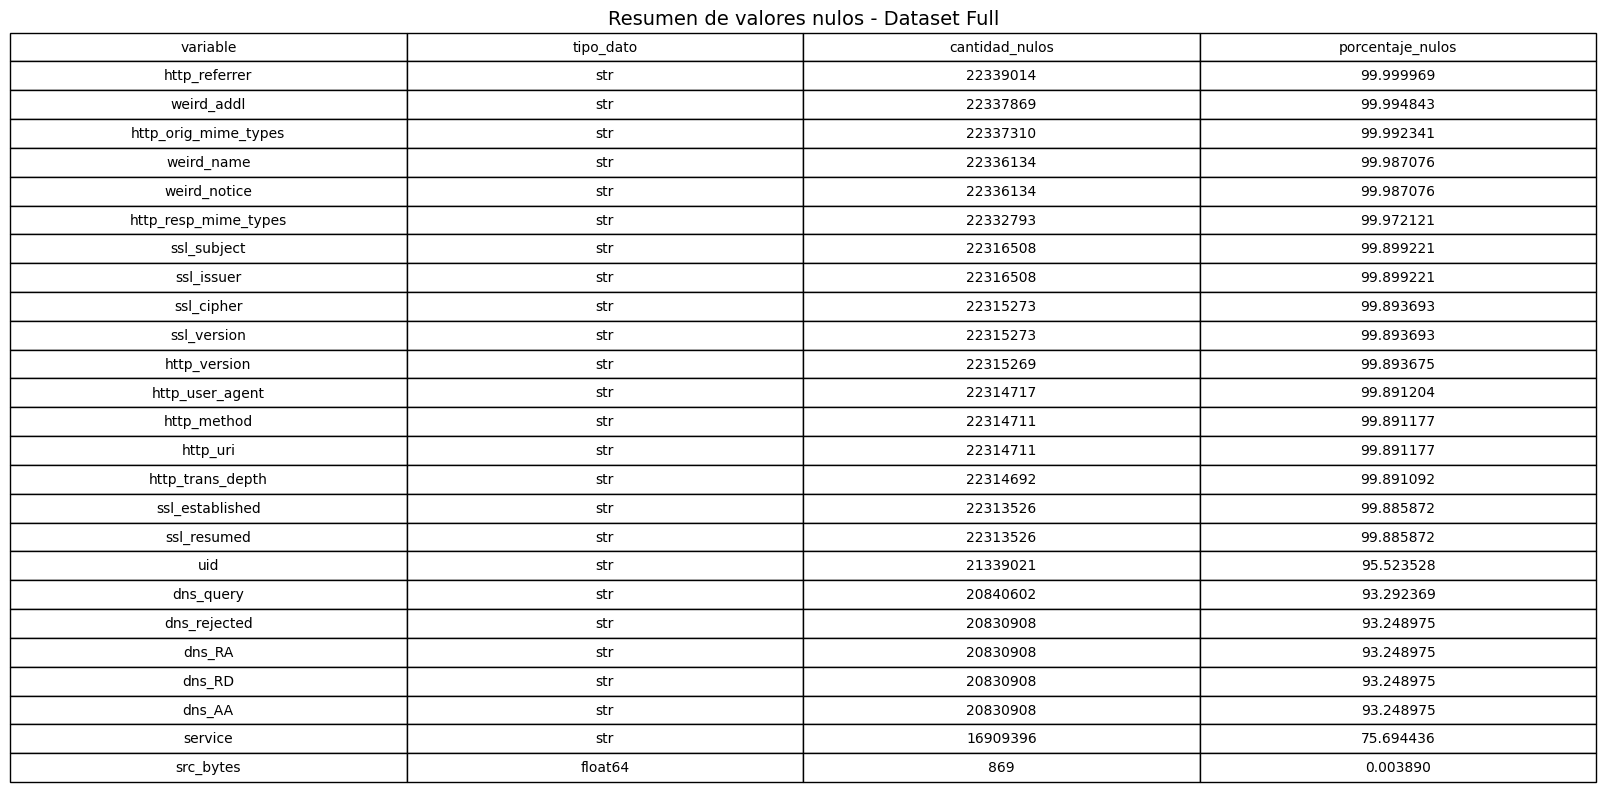

Tabla visual guardada en: /home/bryan_santanderaragon/Proyecto_MBD/images/tabla_resumen_nulos_full.png


In [8]:
import os
import matplotlib.pyplot as plt

# Filtrar solo variables con nulos
null_summary_filtered = null_report[null_report["cantidad_nulos"] > 0].copy()

# Formatear porcentaje
null_summary_filtered["porcentaje_nulos"] = null_summary_filtered["porcentaje_nulos"].map(lambda x: f"{x:.6f}")

# Tomar filas para mostrar
tabla_mostrar = null_summary_filtered.copy()

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=tabla_mostrar.values,
    colLabels=tabla_mostrar.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Resumen de valores nulos - Dataset Full", fontsize=14, pad=20)
plt.tight_layout()

output_table_path = os.path.join(PROJECT_ROOT, "images", "tabla_resumen_nulos_full.png")
os.makedirs(os.path.dirname(output_table_path), exist_ok=True)

plt.savefig(output_table_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tabla visual guardada en:", output_table_path)

In [9]:
# ---------------------------------------------------------
# Paso intermedio:
# Guardar dataset limpio/imputado para evitar repetir limpieza
# ---------------------------------------------------------

full_clean_path = os.path.join(
    config.PROCESSED_PATH,
    "network_full_clean.parquet"
)

df_clean.to_parquet(
    full_clean_path,
    index=False
)

print("Dataset limpio/intermedio guardado en:")
print(full_clean_path)

print("Shape df_clean:", df_clean.shape)

Dataset limpio/intermedio guardado en:
/home/bryan_santanderaragon/Proyecto_MBD/data/processed/network_full_clean.parquet
Shape df_clean: (22339021, 25)


In [10]:
# ---------------------------------------------------------
# Liberar memoria eliminando el dataset original completo
# ---------------------------------------------------------

import gc

if "df_full" in globals():
    del df_full
    print("df_full eliminado de memoria.")

gc.collect()


df_full eliminado de memoria.


20

9. Codificar variables categóricas

In [11]:
# ---------------------------------------------------------
# Preparación del dataset multiclase (sin leakage)
# ---------------------------------------------------------
X_multi, y_multi = preprocessing.prepare_dataset_for_multiclass(
    df=df_clean,
    target_col=config.MULTICLASS_TARGET
)

print("Shape de X_multi:", X_multi.shape)
print("Shape de y_multi:", y_multi.shape)

# ---------------------------------------------------------
# Codificar variables categóricas SOLO de X_multi
# ---------------------------------------------------------
X_multi_encoded = preprocessing.encode_categoricals(
    df=X_multi,
    exclude_columns=[]
)

print("Shape después de encoding multiclase:", X_multi_encoded.shape)
X_multi_encoded.head()

Shape de X_multi: (22339021, 22)
Shape de y_multi: (22339021,)
Shape después de encoding multiclase: (22339021, 22)


,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,http_request_body_len,http_response_body_len,http_status_code
0,1,19,80549.530260,1762852.0,41933215,0,0,252181,14911156,2,...,0,0,0,2,2,2,2,0,0,0
1,2,19,0.000000,0.0,0,6,0,1,63,0,...,0,0,0,2,2,2,2,0,0,0
2,1,19,0.000000,0.0,0,0,0,0,0,0,...,0,0,0,2,2,2,2,0,0,0
3,1,19,0.000000,0.0,0,0,0,0,0,0,...,0,0,0,2,2,2,2,0,0,0
4,2,4,0.000549,0.0,298,12,0,0,0,2,...,0,0,0,2,2,2,2,0,0,0


10. Preparar dataset multiclase

In [12]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# Split del dataset multiclase
# ---------------------------------------------------------
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi_encoded,
    y_multi,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y_multi
)

print("X_train_multi:", X_train_multi.shape)
print("X_test_multi:", X_test_multi.shape)
print("y_train_multi:", y_train_multi.shape)
print("y_test_multi:", y_test_multi.shape)

X_train_multi: (17871216, 22)
X_test_multi: (4467805, 22)
y_train_multi: (17871216,)
y_test_multi: (4467805,)


In [13]:
# Utilizar y descomentar solo en caso de neceistar optimizar la RAM solo despues de sacar los test



#del df_clean
#del df_encoded

In [14]:
# Utilizar y descomentar solo en caso de neceistar optimizar la RAM solo despues de sacar los test

import psutil


process = psutil.Process(os.getpid())
memory_mb = process.memory_info().rss / 1024 / 1024
print(f"RAM usada por el proceso actual: {memory_mb:.2f} MB")

RAM usada por el proceso actual: 17582.79 MB


11. Guardar artefactos multiclase full

In [15]:
# ---------------------------------------------------------
# Guarda los conjuntos de entrenamiento y prueba
# del flujo full multiclase
# ---------------------------------------------------------
X_train_multi.to_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_train_full_multiclass.parquet"),
    index=False
)

X_test_multi.to_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_multiclass.parquet"),
    index=False
)

pd.Series(y_train_multi).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_train_full_multiclass.csv"),
    index=False
)

pd.Series(y_test_multi).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_multiclass.csv"),
    index=False
)

print("Datasets multiclase full guardados.")

Datasets multiclase full guardados.


12. Guardar encoders full

In [16]:
# ---------------------------------------------------------
# Guardar encoders del flujo multiclase
# ---------------------------------------------------------
joblib.dump(
    preprocessing.encoders,
    os.path.join(config.FULL_ARTIFACTS_DIR, "feature_encoders_full_multiclass.pkl")
)

print("Encoders multiclase full guardados.")



Encoders multiclase full guardados.


13. Preparacion del dataset binario

In [17]:
# ---------------------------------------------------------
# Preparación del dataset binario (sin leakage)
# ---------------------------------------------------------
X_bin, y_bin = preprocessing.prepare_dataset_for_binary(
    df=df_clean,
    target_col=config.BINARY_TARGET
)

print("Shape de X_bin:", X_bin.shape)
print("Shape de y_bin:", y_bin.shape)

# ---------------------------------------------------------
# Codificar variables categóricas SOLO de X_bin
# ---------------------------------------------------------
X_bin_encoded = preprocessing.encode_categoricals(
    df=X_bin,
    exclude_columns=[]
)

print("Shape después de encoding binario:", X_bin_encoded.shape)

# ---------------------------------------------------------
# Split del dataset binario
# ---------------------------------------------------------
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin_encoded,
    y_bin,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y_bin
)

print("X_train_bin:", X_train_bin.shape)
print("X_test_bin:", X_test_bin.shape)
print("y_train_bin:", y_train_bin.shape)
print("y_test_bin:", y_test_bin.shape)

Shape de X_bin: (22339021, 22)
Shape de y_bin: (22339021,)
Shape después de encoding binario: (22339021, 22)
X_train_bin: (17871216, 22)
X_test_bin: (4467805, 22)
y_train_bin: (17871216,)
y_test_bin: (4467805,)


Guardar el dataset para el analisis binario

In [18]:
# ---------------------------------------------------------
# Guarda datasets del flujo full binario
# ---------------------------------------------------------
X_train_bin.to_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_train_full_binary.parquet"),
    index=False
)

X_test_bin.to_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_binary.parquet"),
    index=False
)

pd.Series(y_train_bin).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_train_full_binary.csv"),
    index=False
)

pd.Series(y_test_bin).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_binary.csv"),
    index=False
)

print("Datasets binarios full guardados.")

Datasets binarios full guardados.


In [19]:
binary_encoder_path = os.path.join(
    config.FULL_ARTIFACTS_DIR,
    "feature_encoders_full_binary.pkl"
)

joblib.dump(preprocessing.encoders, binary_encoder_path)

print("✔ Encoders binarios guardados en:")
print(binary_encoder_path)

✔ Encoders binarios guardados en:
/home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full/feature_encoders_full_binary.pkl


Visualizar reporte de nulos

15. Verificar contenido de la carpeta de artefactos full

In [23]:
# ---------------------------------------------------------
# Lista todos los artefactos generados
# para verificar que el pipeline full quedó listo
# ---------------------------------------------------------
print("Contenido de FULL_ARTIFACTS_DIR:")
for f in os.listdir(config.FULL_ARTIFACTS_DIR):
    print("-", f)

Contenido de FULL_ARTIFACTS_DIR:
- X_test_full_binary.parquet
- binary_model_results_full.csv
- evaluation_summary_full.csv
- shap_feature_importance_full_xgb.csv
- X_train_full_multiclass.parquet
- X_train_full_binary.parquet
- dnn_binary_predictions_full.csv
- dnn_binary_full.keras
- rf_multiclass_full.pkl
- xgb_multiclass_full.pkl
- reporte_nulos_dataset_full.xlsx
- dnn_multiclass_full.keras
- xgb_predictions_full.csv
- y_test_full_multiclass.csv
- scaler_multiclass_full.pkl
- X_test_full_multiclass.parquet
- global_results_summary.csv
- resumen_imputacion_dataset_full.xlsx
- comparison_multiclass_models.png
- scaler_binary_full.pkl
- lgb_binary_predictions_full.csv
- rf_predictions_full.csv
- lgb_binary_full.pkl
- rf_binary_full.pkl
- multiclass_model_results_full.csv
- lgb_multiclass_full.pkl
- .ipynb_checkpoints
- binary_internal_comparison.csv
- dnn_multiclass_predictions_full.csv
- y_train_full_multiclass.csv
- dnn_binary_results_full.csv
- target_encoder_full_multiclass.pkl
- 

Como este notebook puede tardar bastante por el volumen, es recomendable ejecutarlo por bloques:

carga y consolidación
limpieza
encoding
multiclase
binario
guardado